# Encuesta mundial de salud escolar, Argentina 2018 (EMSE 2018)

## 1. Introduccion

### 1.1 Contexto
Encuenta realiza en Argentina entre estudiantes en 2018

### 1.2 Objetivo
El objetivo principal de la tercera Encuesta Mundial de Salud Escolar 2018 (EMSE 2018) fue proporcionar datos precisos sobre comportamientos relativos a la salud y los factores de riesgo y de protección entre estudiantes de Argentina


### 1.3 Tamaño
El dataset ocupa aproximadamente 100 MB y contiene 57K filas


## 2. Carga e Inspeccion Inicial

### 2.1 Importacion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from IPython.display import display
import seaborn as sns
from scipy.stats import entropy


### 2.2 Carga del Dataset

In [2]:
# Cargamos un diccionario con las traducciones de los codigos de preguntas
with open("data/traducciones.json", "r") as file:
    traducciones = json.load(file)
    traducciones_df = pd.DataFrame(traducciones.items())

# Cargamos el dataset con los datos
df = pd.read_csv("data/EMSE_DatosAbiertos.csv")

### 2.3 Informacion General

In [3]:
df.shape

(56981, 309)

In [4]:
df.isna().sum()

sitio              0
record             0
q1               108
texto_q1         108
q2               536
                ... 
qnpe5g          1949
texto_qnpe5g       0
weight             0
stratum            0
psu                0
Length: 309, dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56981 entries, 0 to 56980
Columns: 309 entries, sitio to psu
dtypes: float64(154), int64(3), object(152)
memory usage: 134.3+ MB


Observamos que el dataset cuenta con 56981 filas y 309 columnas o features.

In [6]:
df.head()

,sitio,record,q1,texto_q1,q2,texto_q2,q3,texto_q3,q4,q5,...,texto_qnpa5g,qnpa7g,texto_qnpa7g,qnpe3g,texto_qnpe3g,qnpe5g,texto_qnpe5g,weight,stratum,psu
0,AG,1,3.0,13 años,2.0,Femenino,2.0,9no grado nivel Primario/Polimodal o 2do año n...,NaN,NaN,...,Si,1.0,Si,2.0,No,2.0,No,457.09,201801010,19
1,AG,2,3.0,13 años,2.0,Femenino,2.0,9no grado nivel Primario/Polimodal o 2do año n...,NaN,NaN,...,Si,2.0,No,2.0,No,2.0,No,457.09,201801010,19
2,AG,3,4.0,14 años,1.0,Masculino,4.0,2do año/11vo grado nivel Polimodal o 4to año n...,1.67,56.0,...,Si,2.0,No,2.0,No,2.0,No,261.44,201801010,19
3,AG,4,6.0,16 años,1.0,Masculino,2.0,9no grado nivel Primario/Polimodal o 2do año n...,1.73,70.0,...,No,2.0,No,1.0,Si,1.0,Si,550.90,201801010,19
4,AG,5,3.0,13 años,2.0,Femenino,2.0,9no grado nivel Primario/Polimodal o 2do año n...,NaN,NaN,...,No,2.0,No,2.0,No,2.0,No,457.09,201801010,19


## 3. Comprension de Variables

Se puede observar que el dataset cuenta con 2 columnas para cada pregunta del cuestionario, una numerica y una codificada en texto. Todas las respuestas a las preguntas son de tipo **categorica** y tienen asociado su correspondiente lista de codigos validos presentes en la documentacion.

In [7]:
# Obtenemos todas las columnas que comiencen con "q", 
# aquellas que representan un pregunta del cuestionario.
# Evitamos las columnas que representan la misma pregunta pero con
# su respuesta en formato textual.
df[df.columns[pd.Series(df.columns).str.startswith('q')]].columns

Index(['q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q10', 'q15', 'q16', 'q17',
       ...
       'qnff2g', 'qnff3g', 'qntob2g', 'qnnotb2g', 'qnbcanyg', 'qnc1g',
       'qnpa5g', 'qnpa7g', 'qnpe3g', 'qnpe5g'],
      dtype='object', length=153)

Observamos entonces que el cuestionario cuenta con 153 preguntas.

## 4. Preseleccion de Variables

Para simplificar el analisis vamos a hacer una preseleccion de las variables que consideramos, a grandes razgos, que podrian estar relacionadas al objetivo final.

In [8]:
from matplotlib.ticker import PercentFormatter
from textwrap import fill
from matplotlib.lines import Line2D

def get_colors(n):
    return plt.cm.tab20(np.arange(n))

def print_question(q, figsize=(12, 5)):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    fig.suptitle(f"{q}: {traducciones[q]}")

    series = df[q]
    labels = df[[q, "texto_" + q]].drop_duplicates().sort_values(by=q)["texto_" + q].dropna()
    labels = [fill(label, width=24) for label in labels]

    # --- Plot 1: Value frequencies as percentages ---
    value_pct = (
        series.value_counts(dropna=True, normalize=True)
        .sort_index()
        .mul(100)
    )
   # print(f'El camino a la solución: {last_node.path()}')
    colors = get_colors(len(value_pct))
    max_pct = value_pct.max()
    custom_line = Line2D([0], [0], color='blue') 
    value_pct.plot(kind="bar", ax=ax1, color=colors, label= (f'Entropia de Shanon: {round(entropy(value_pct),2)}'))
    ax1.legend(loc='upper right',facecolor='lightgrey')
    #value_pct.legend()
    ax1.set_title("Distribucion de Respuestas")
        #legend("Entropia de Shanon: ",entropy(value_pct))
    ax1.set_ylabel("Frecuencia (%)")
    ax1.set_xlabel("Respuesta")
    ax1.set_ylim(0, max(100, max_pct * 1.15))
    ax1.yaxis.set_major_formatter(PercentFormatter())
    ax1.set_xticklabels(
        labels[:len(value_pct)],
        rotation=45,
        ha="right"
    )

    # Add labels on bars
    for container in ax1.containers:
        ax1.bar_label(container, fmt="%.1f%%")

    # --- Plot 2: NaN vs Non-NaN percentages ---
    nan_pct = series.isna().mean() * 100
    non_nan_pct = 100 - nan_pct
    max_pct = max(nan_pct, non_nan_pct)

    ax2.barh(
        ["No nulos", "Nulos"],
        [non_nan_pct, nan_pct],
        color=colors
    )
    ax2.set_title("Respuestas Nulas")
    ax2.set_xlabel("Frecuencia (%)")
    ax2.xaxis.set_major_formatter(PercentFormatter())
    ax2.set_xlim(0, max(100, max_pct * 1.15))

    # Add labels on bars
    for container in ax2.containers:
        ax2.bar_label(container, fmt="%.1f%%")

    plt.tight_layout()
    plt.show()
 

### 4.1 Target

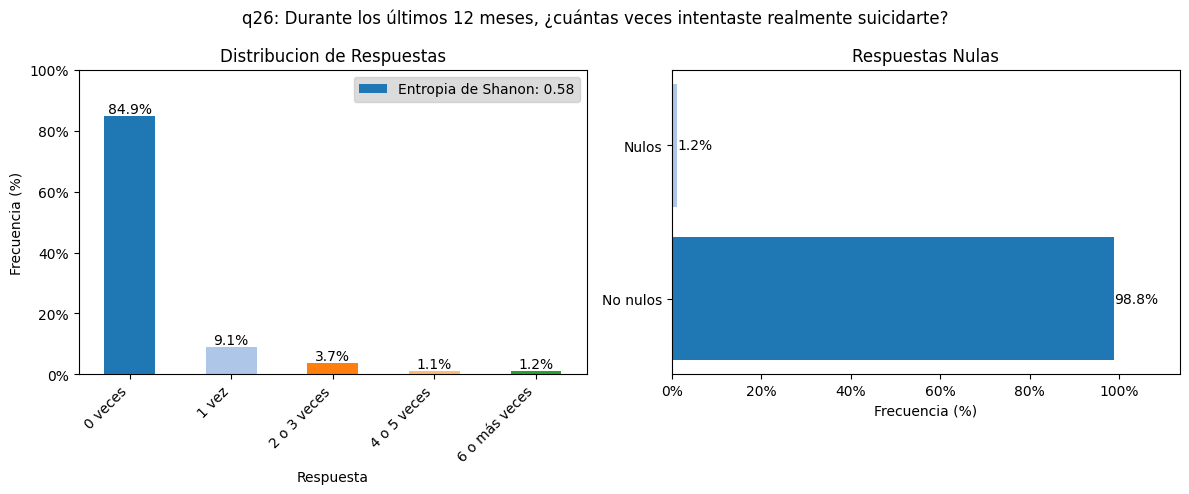

In [9]:
target = "q26"
print_question(target)

### 4.2 Variables Demograficas

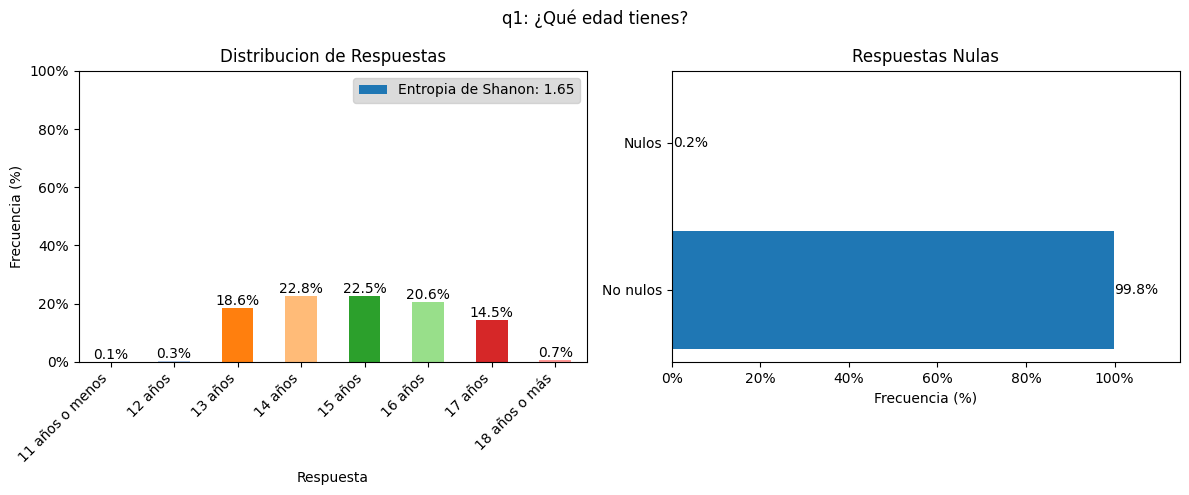

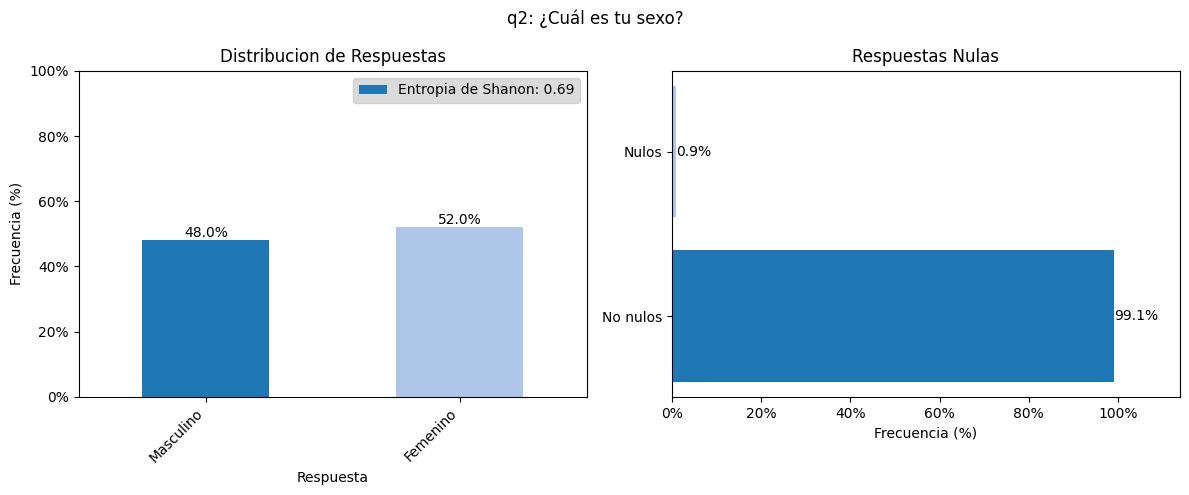

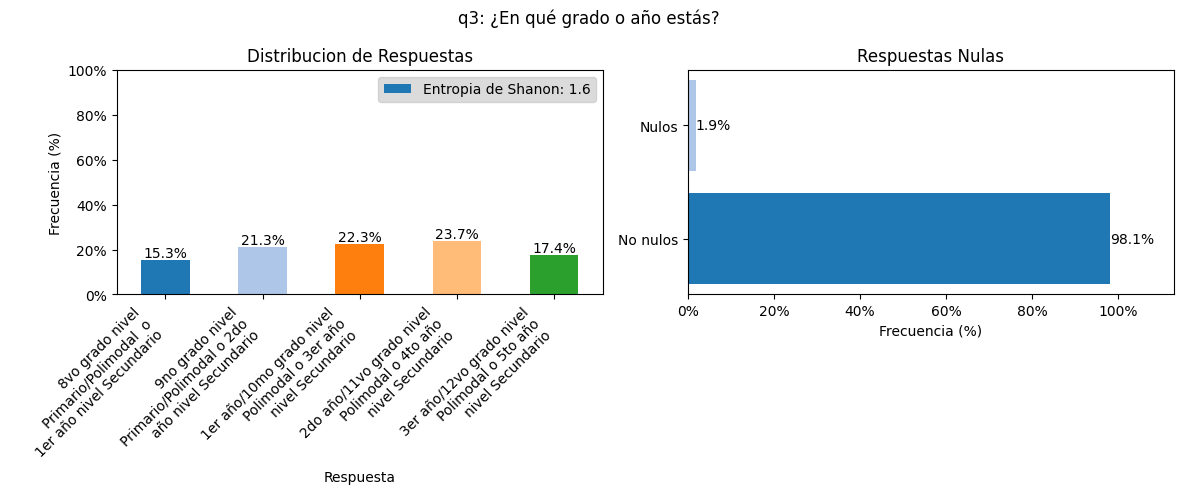

In [10]:
demographic = ["q1", "q2", "q3"]

for q in demographic:
    print_question(q)

### 4.3 Variables de Salud Mental

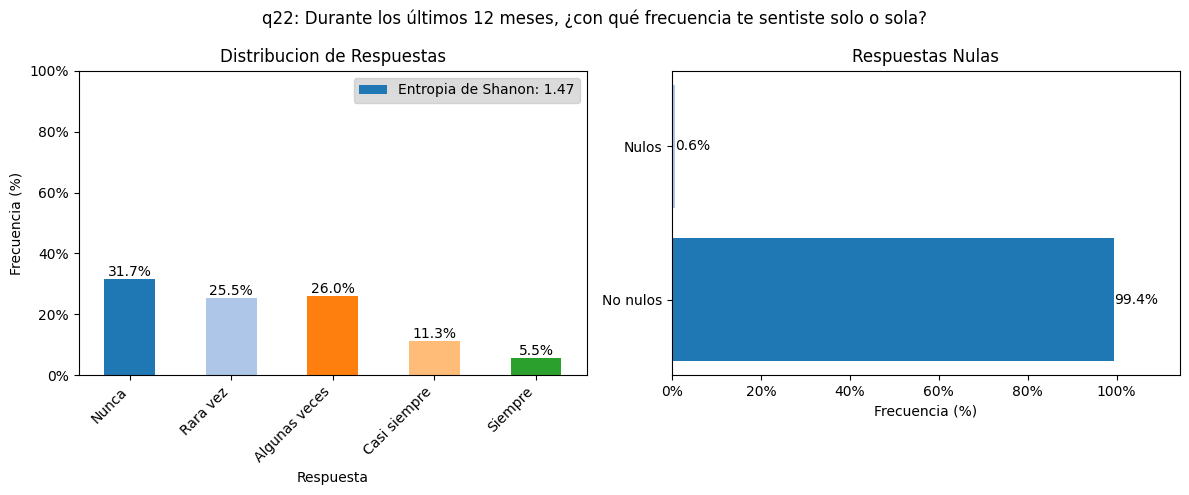

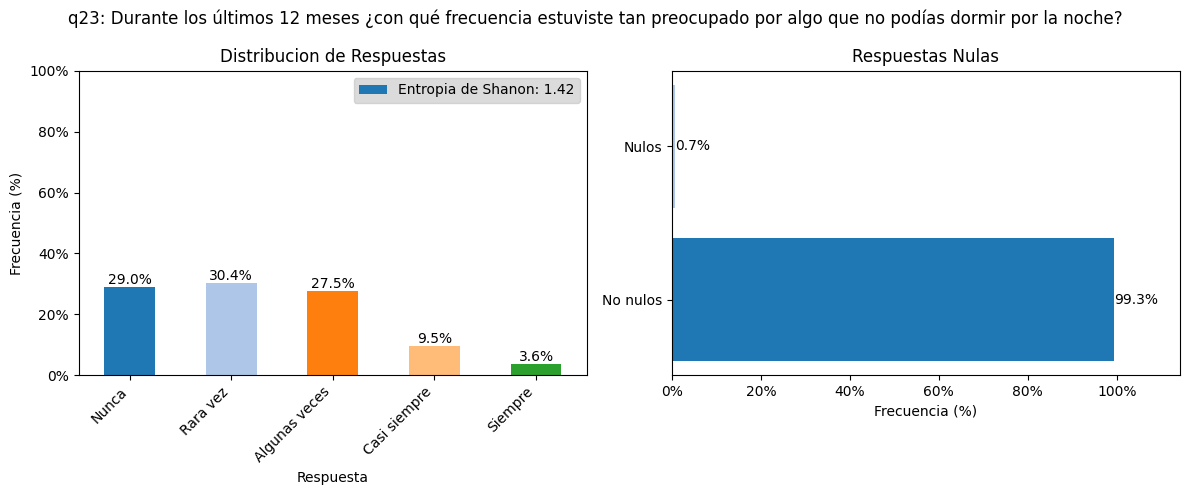

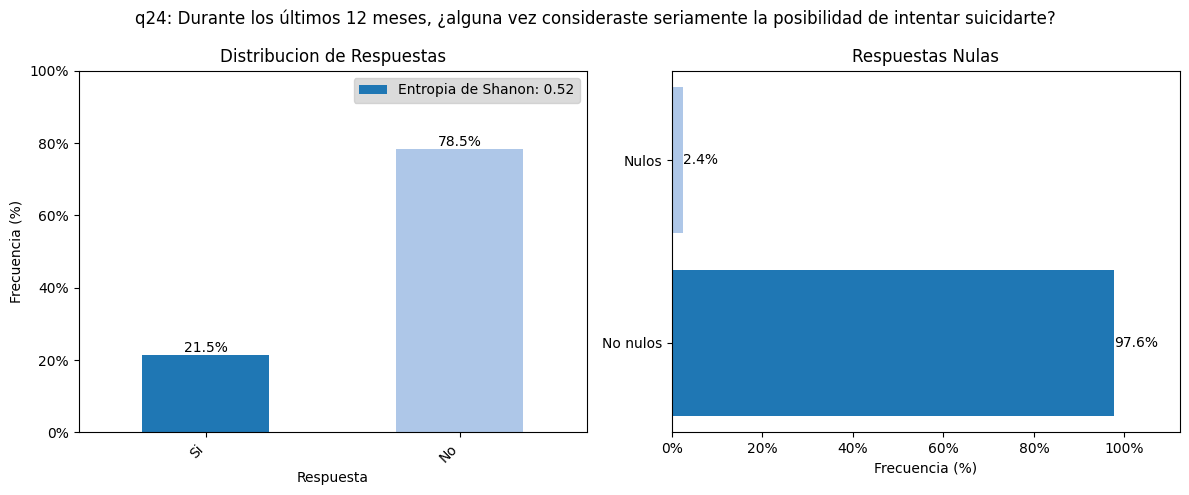

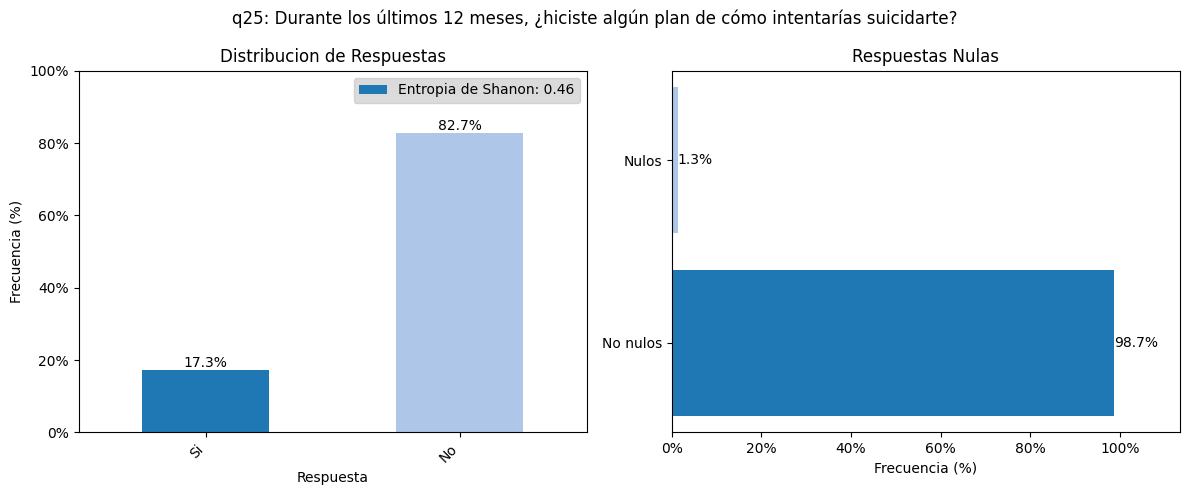

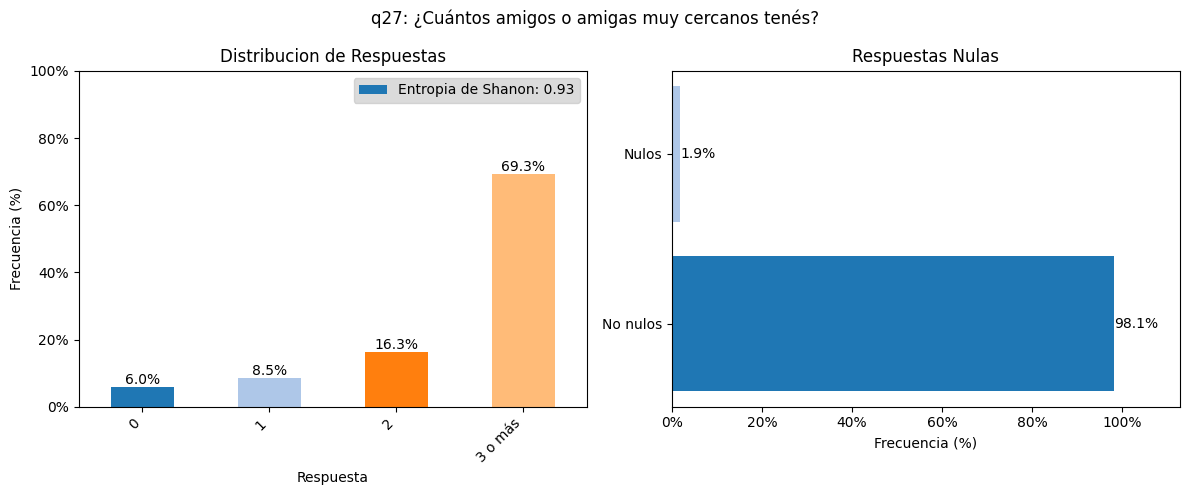

In [11]:
salud_mental = ["q22", "q23", "q24", "q25", "q27"]

for q in salud_mental:
    print_question(q)

### 4.4 Violencia y Bullying

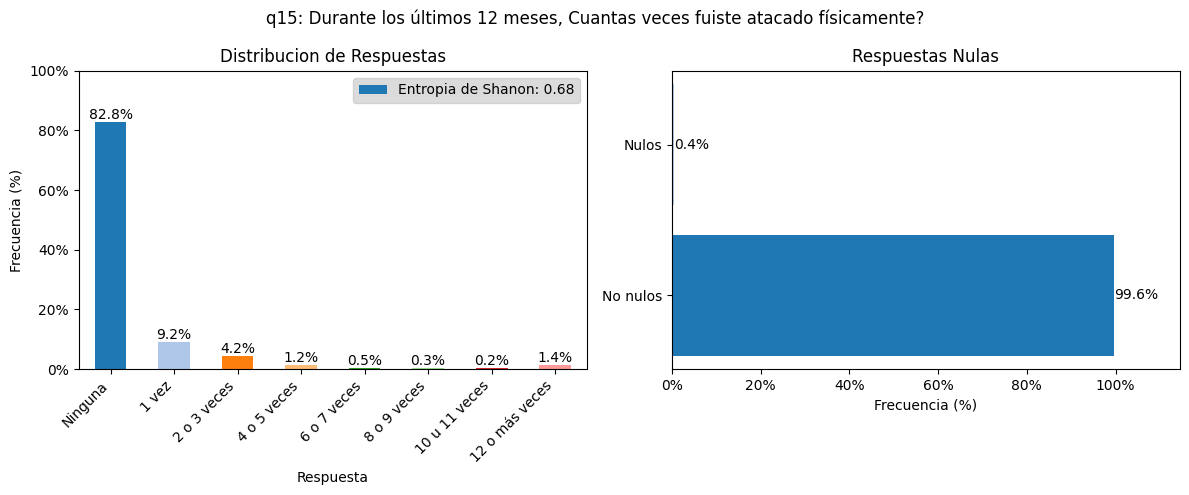

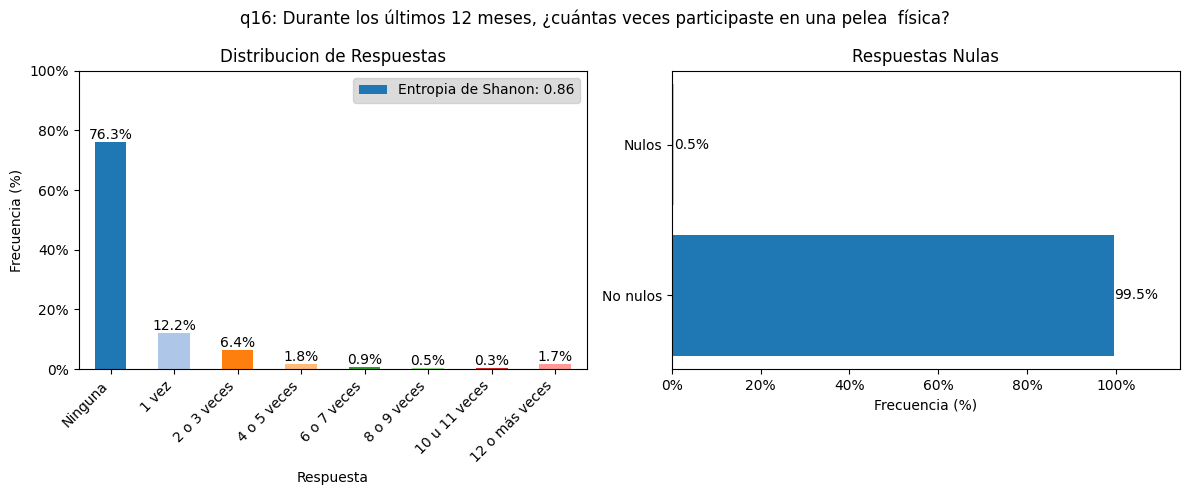

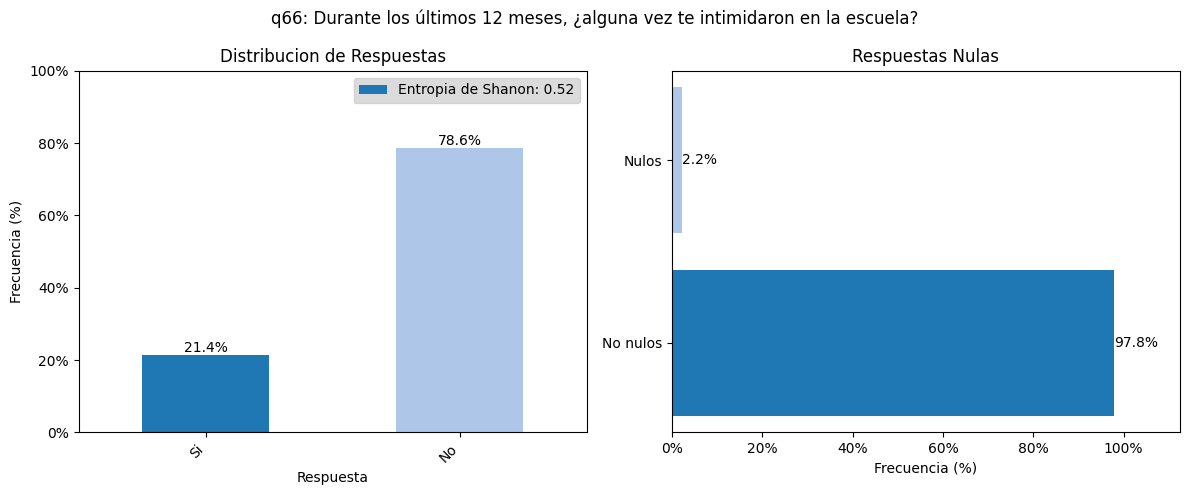

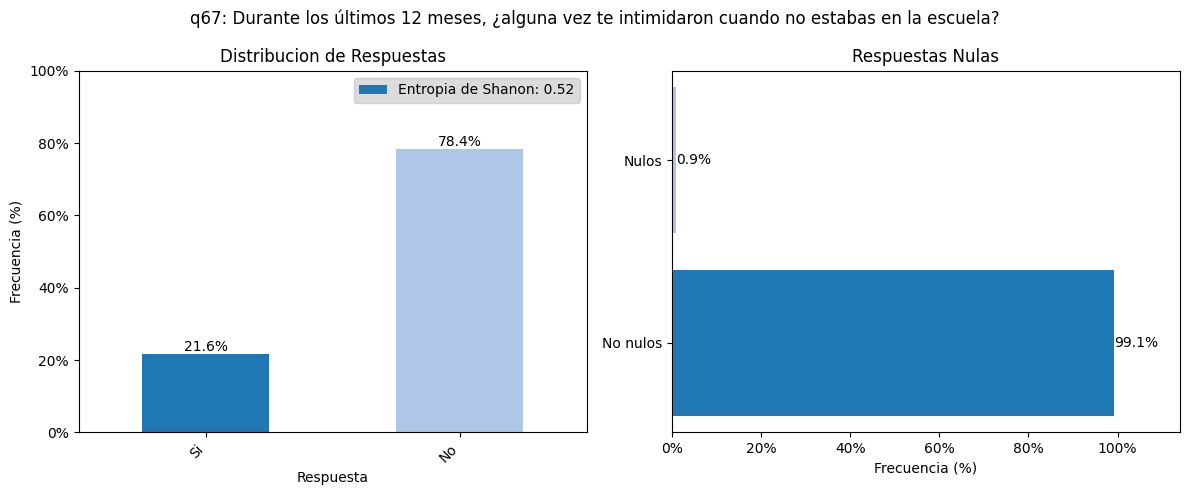

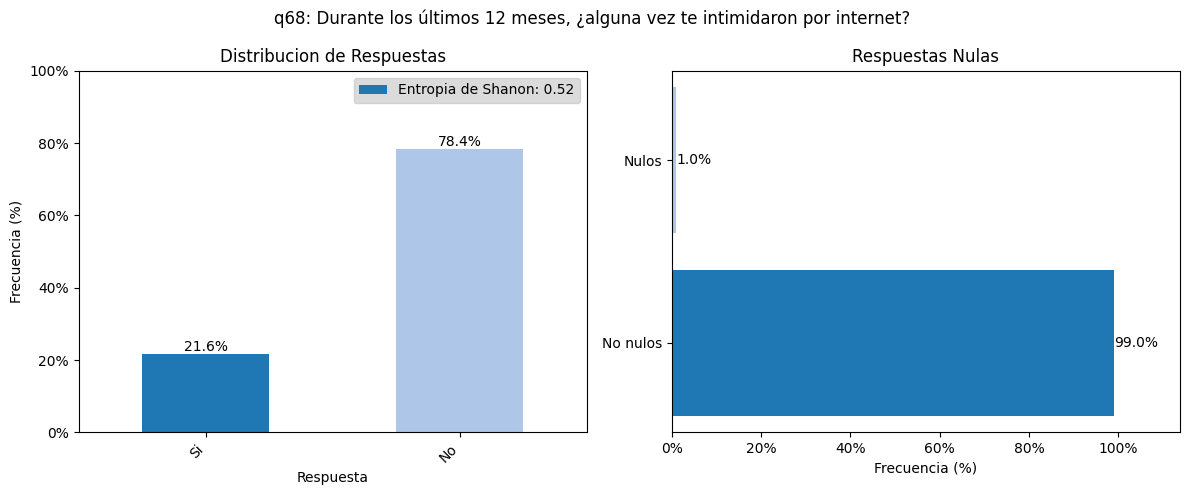

In [12]:
violencia = ["q15", "q16", "q66", "q67", "q68"]

for q in violencia:
    print_question(q)

### 4.5 Apoyo Familiar

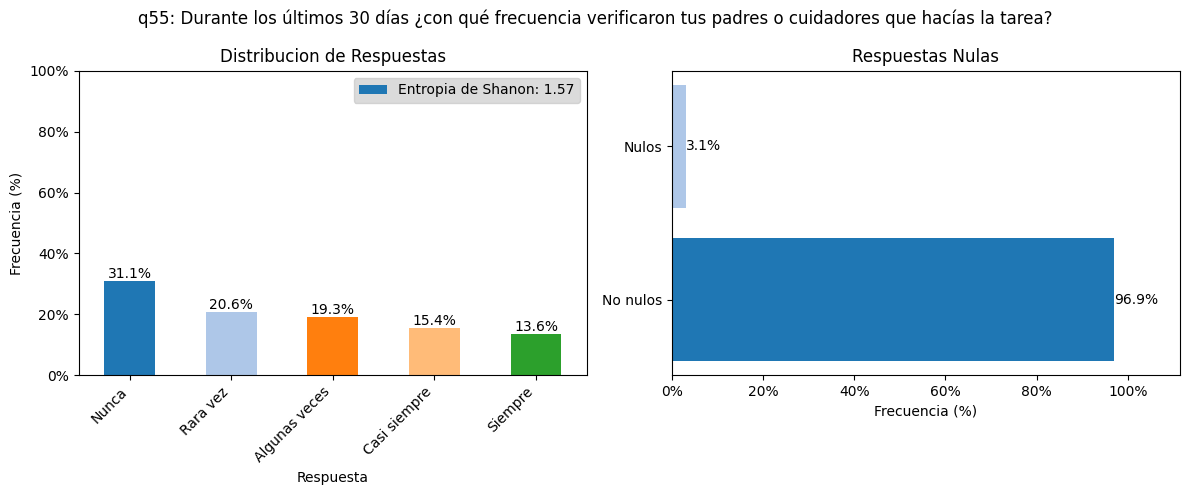

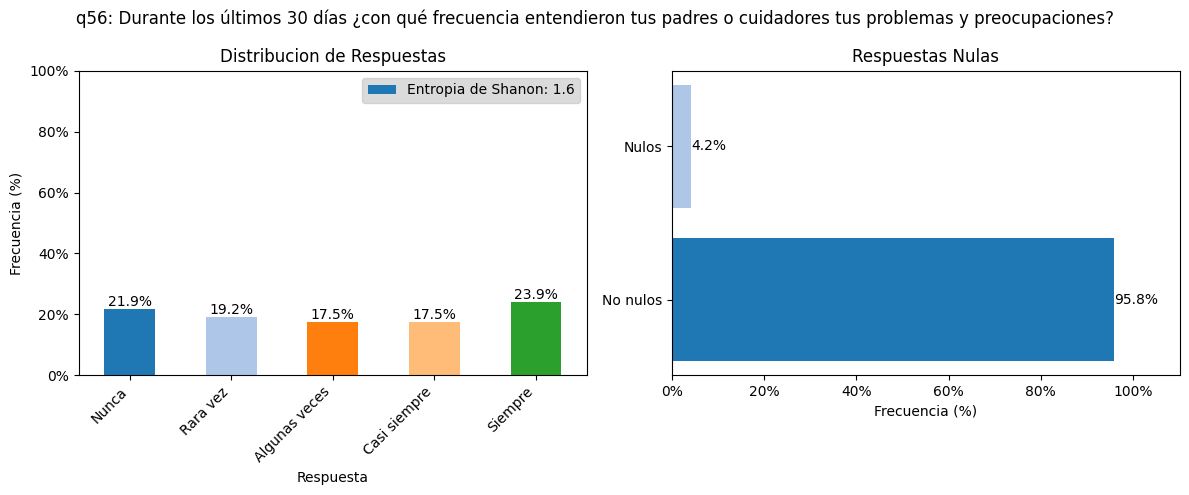

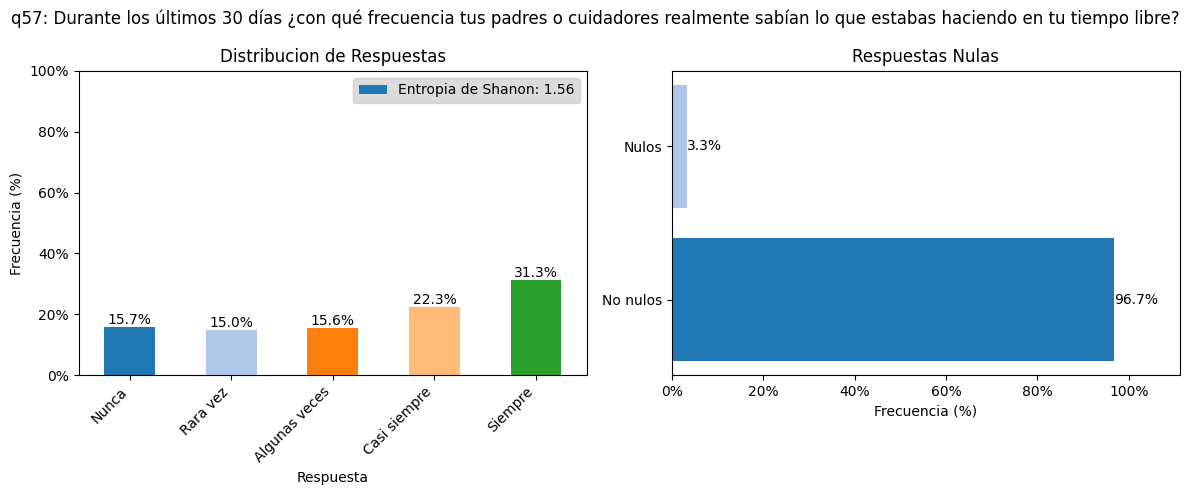

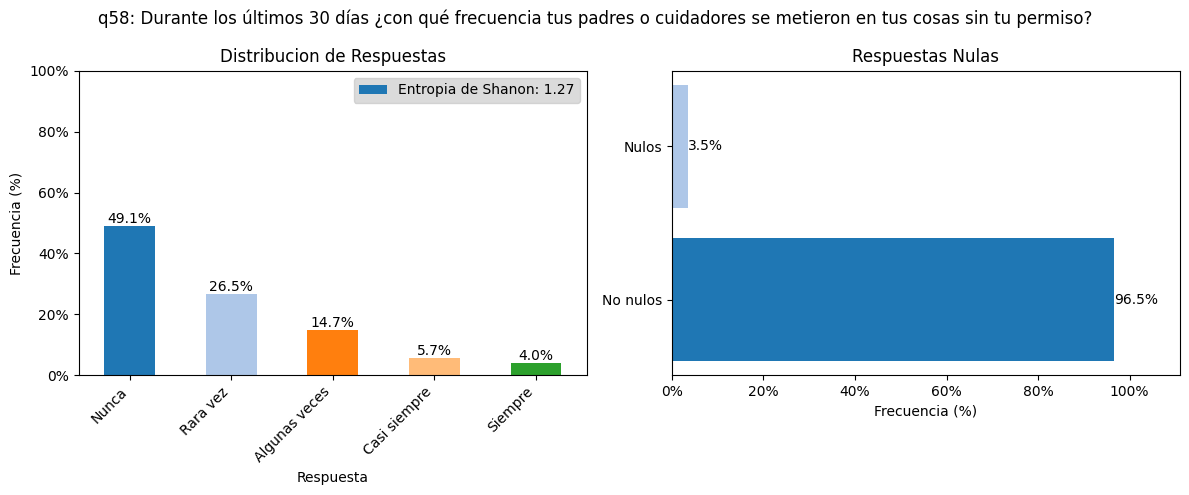

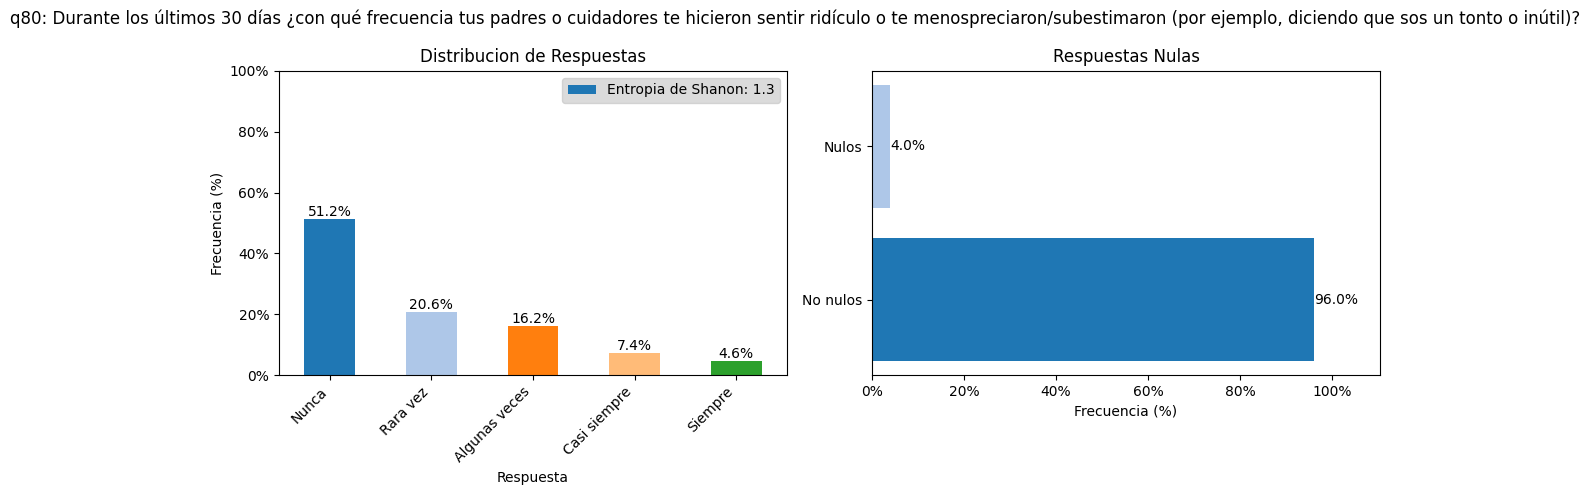

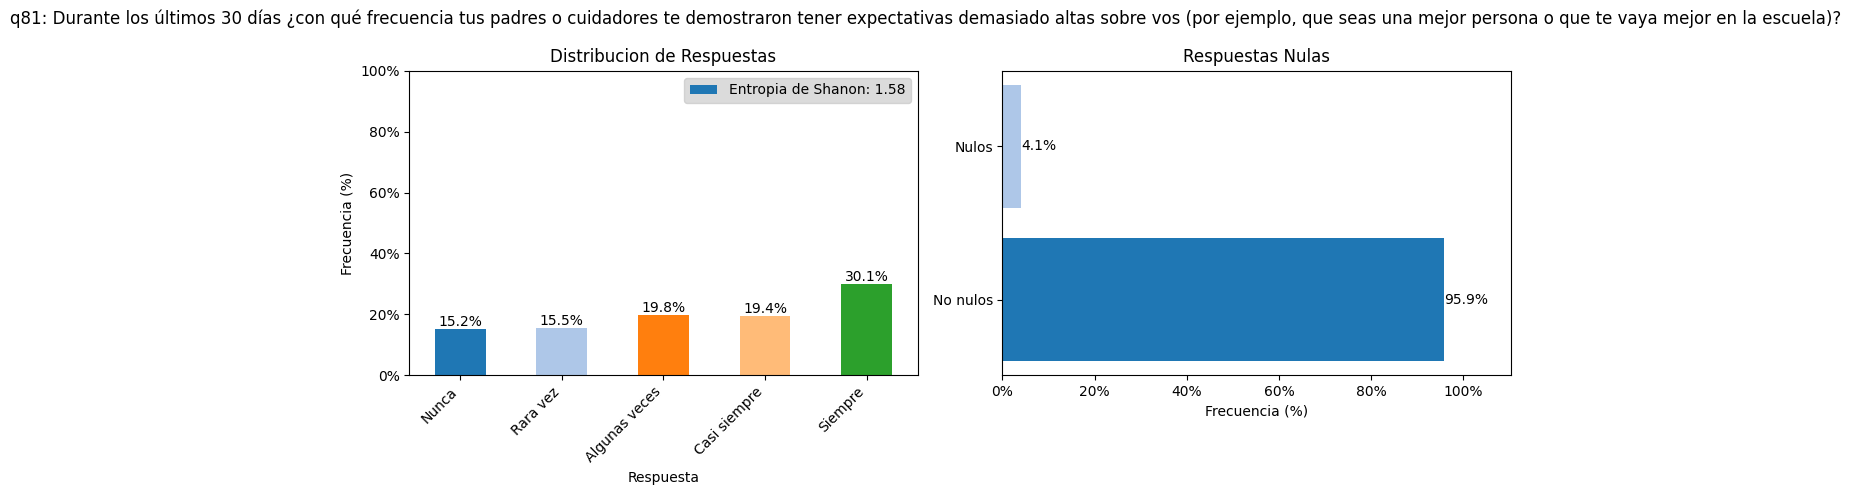

In [13]:
apoyo = ["q55", "q56", "q57", "q58", "q80", "q81"]

for q in apoyo:
    print_question(q)

### 4.6 Consumo de Sustancias

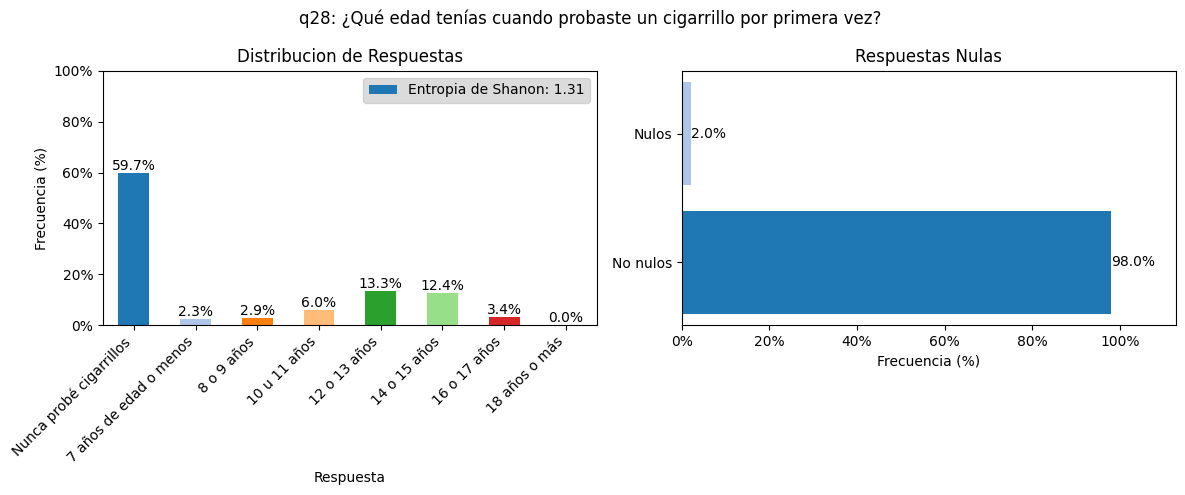

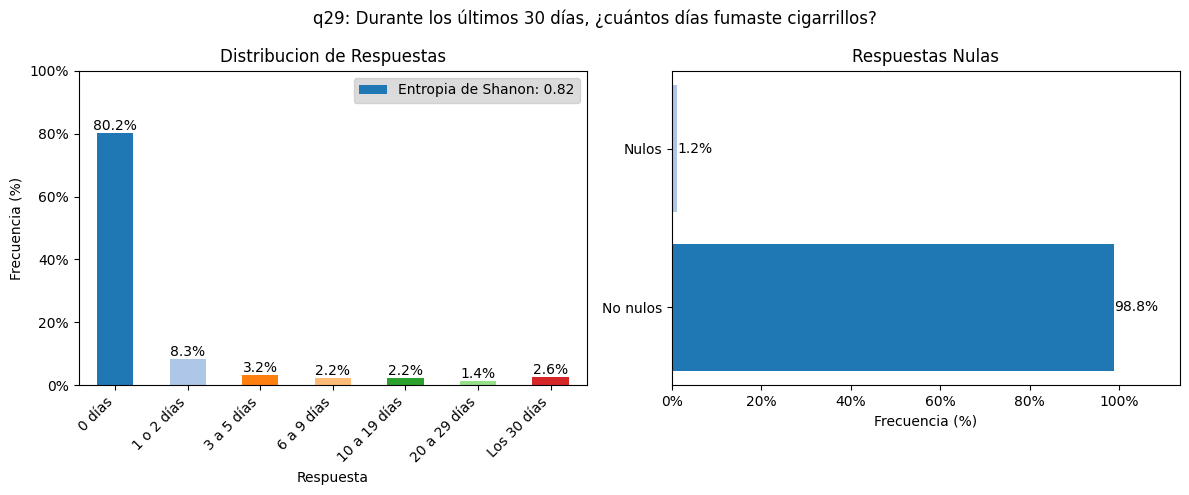

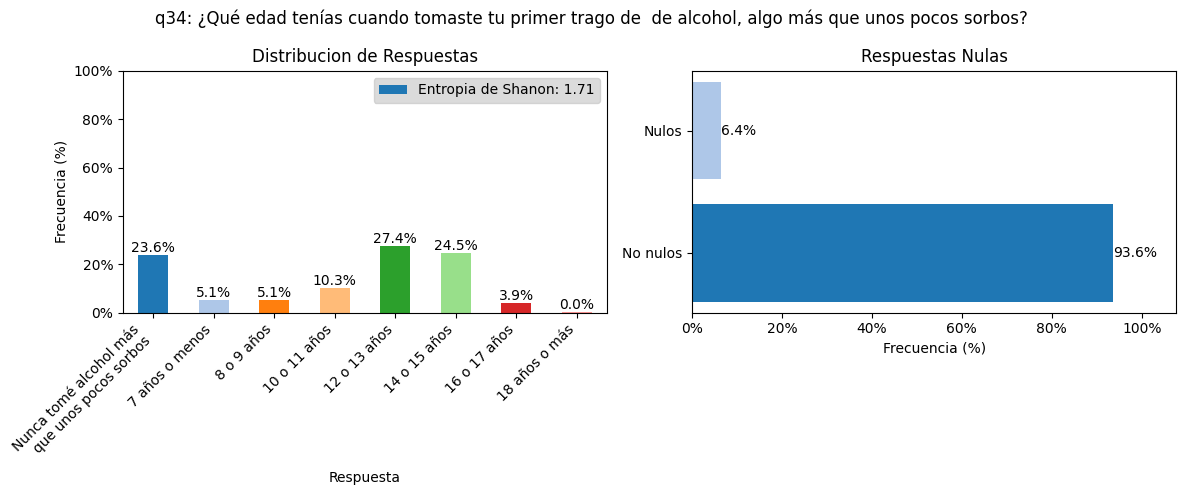

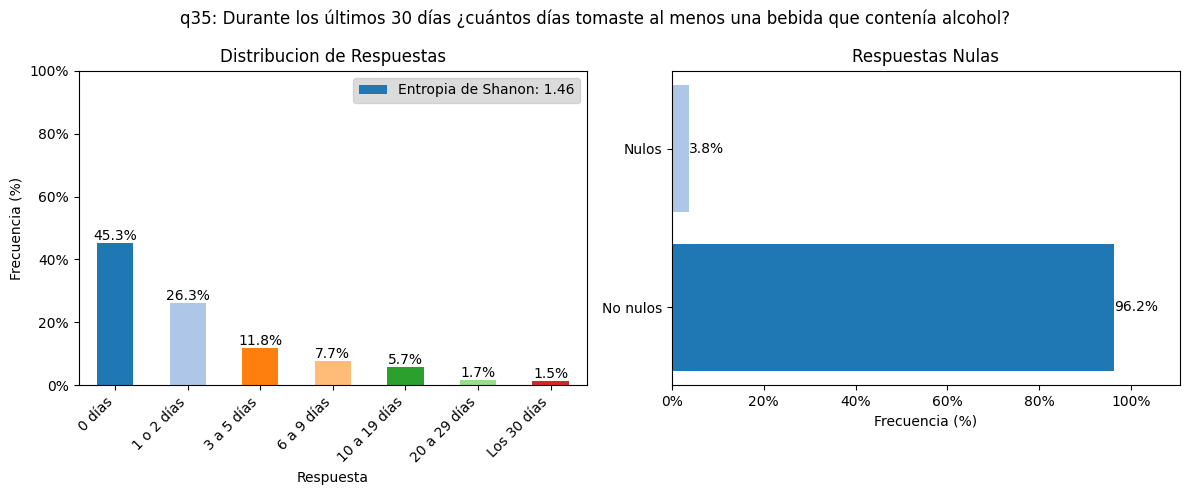

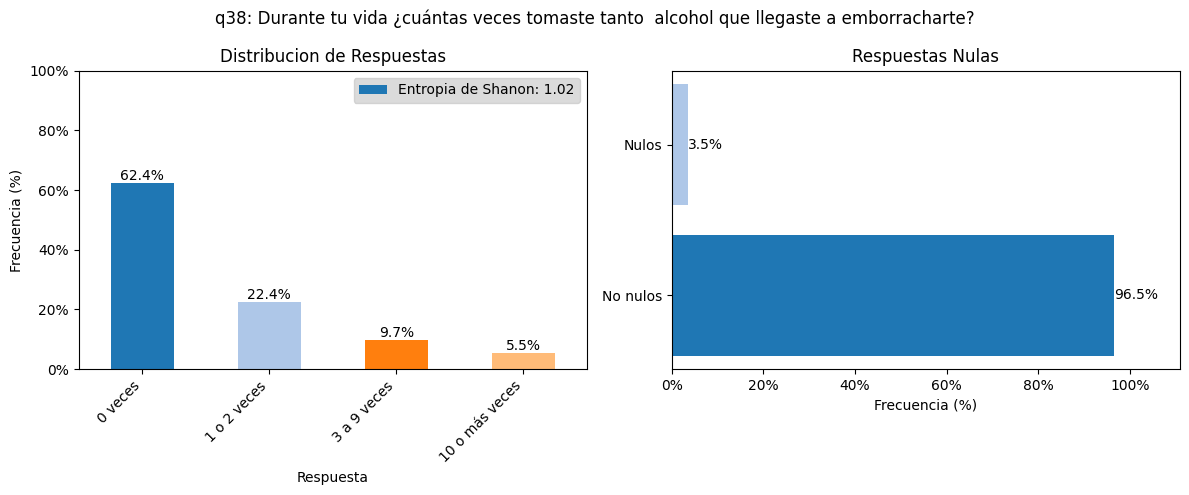

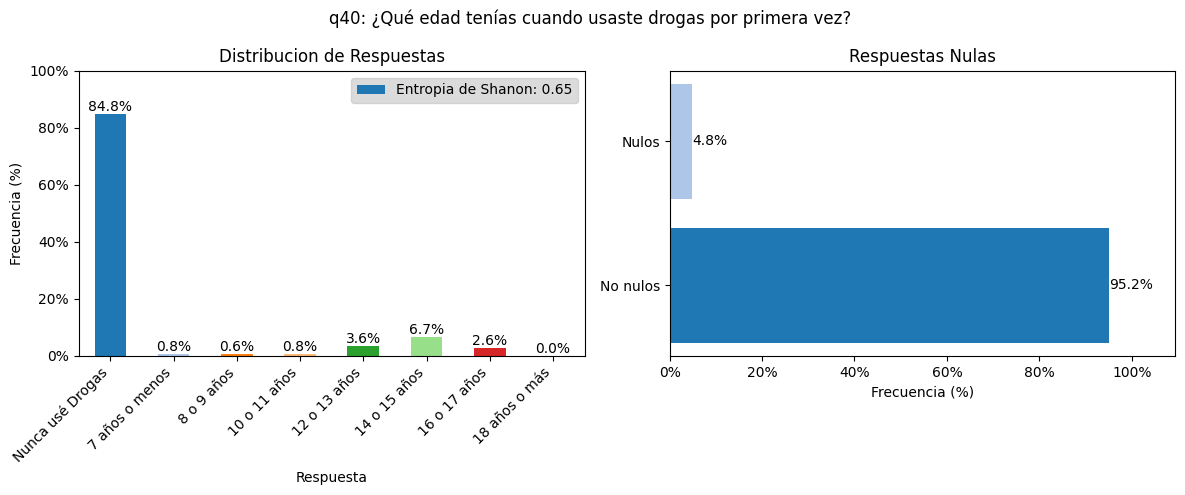

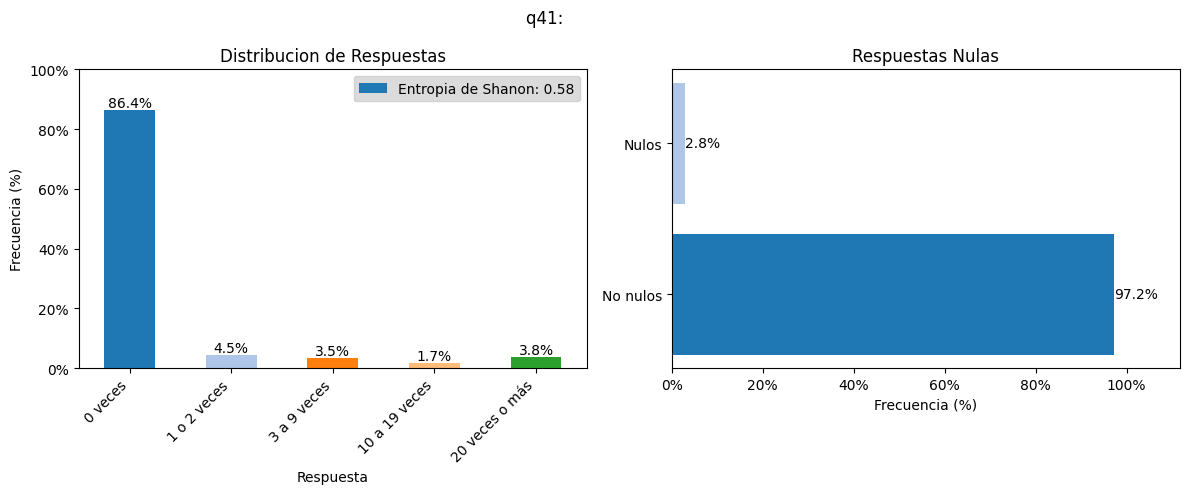

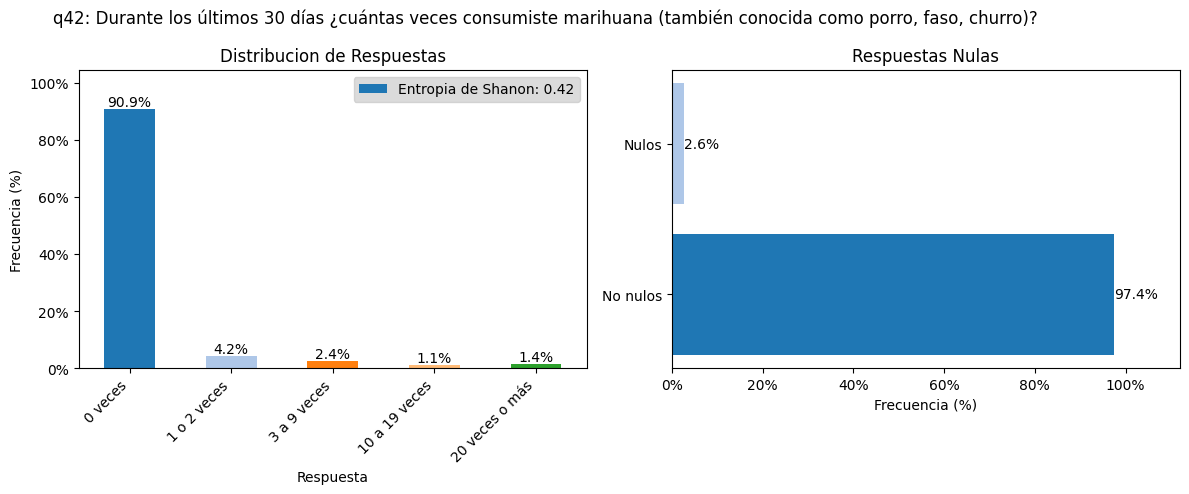

In [14]:
sustancias = ["q28", "q29", "q34", "q35", "q38", "q40", "q41", "q42"]

for q in sustancias:
    print_question(q)

### 4.7 Factores Sociales y Escolares

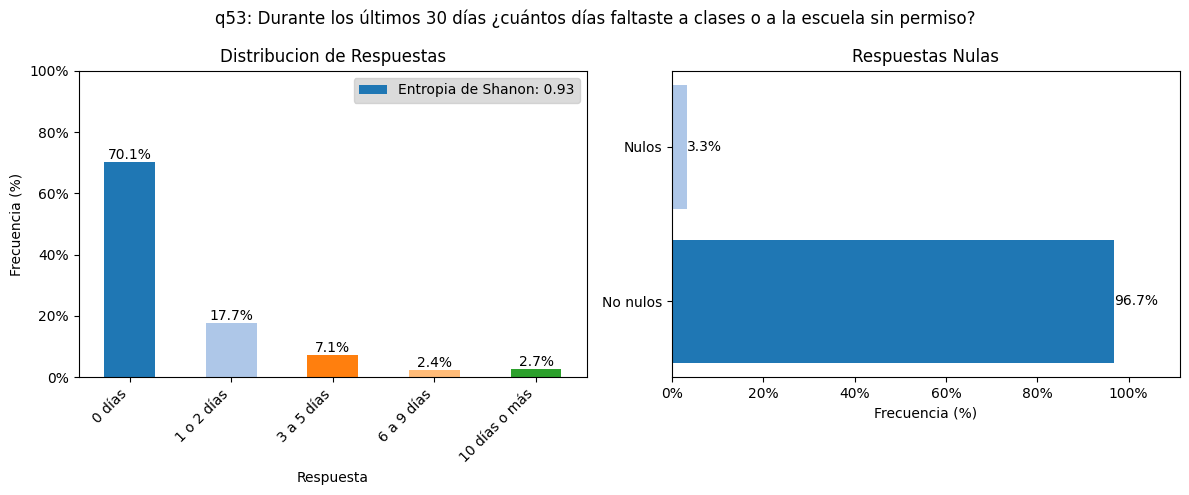

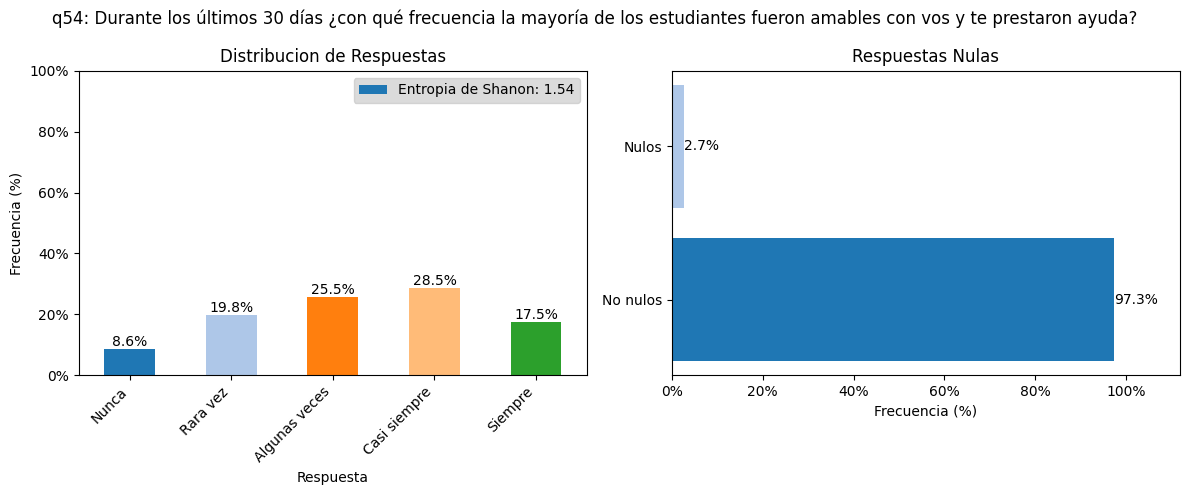

In [15]:
sociales = ["q53", "q54"]

for q in sociales:
    print_question(q)

### 4.8 Factores Socioeconomicos

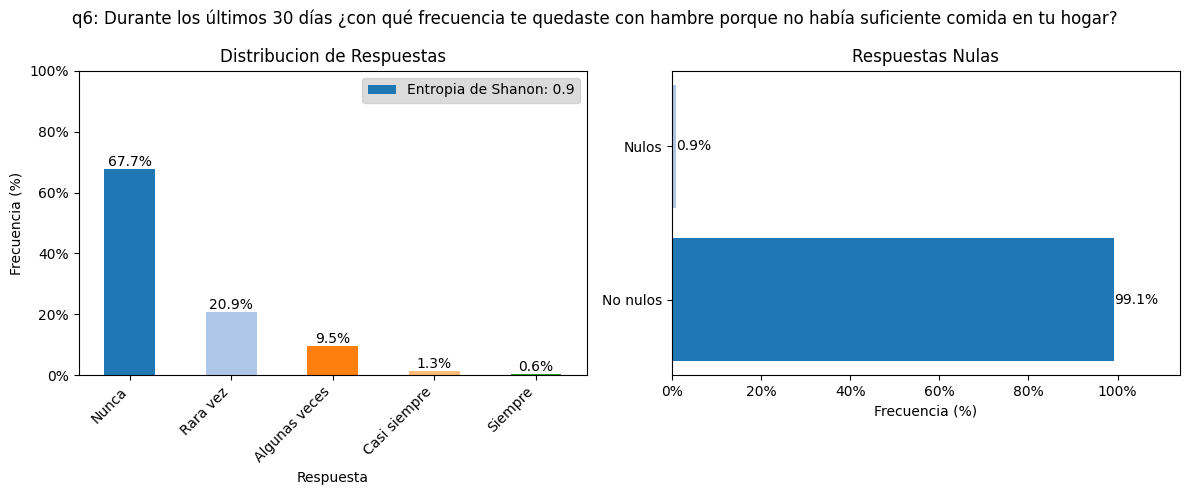

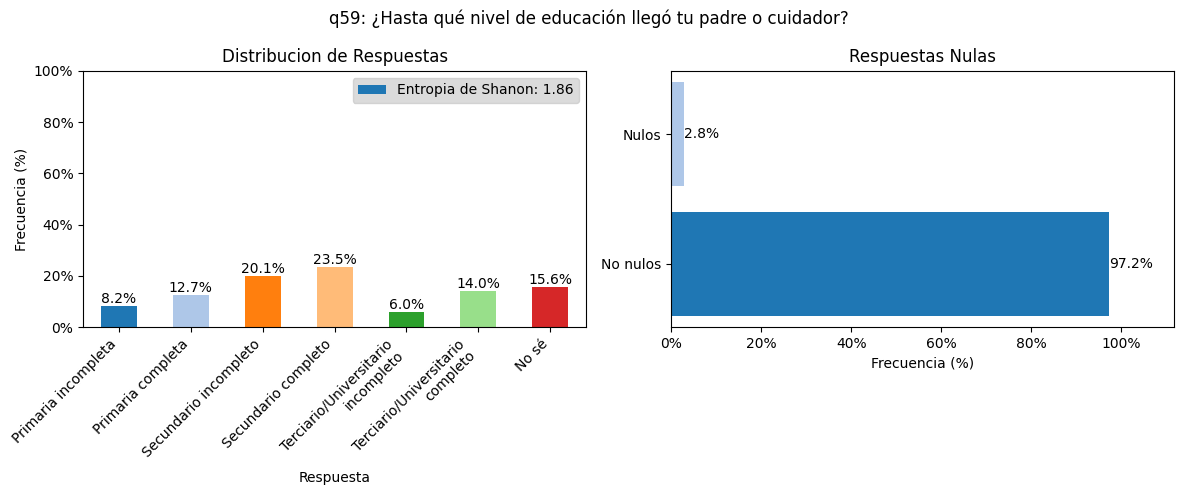

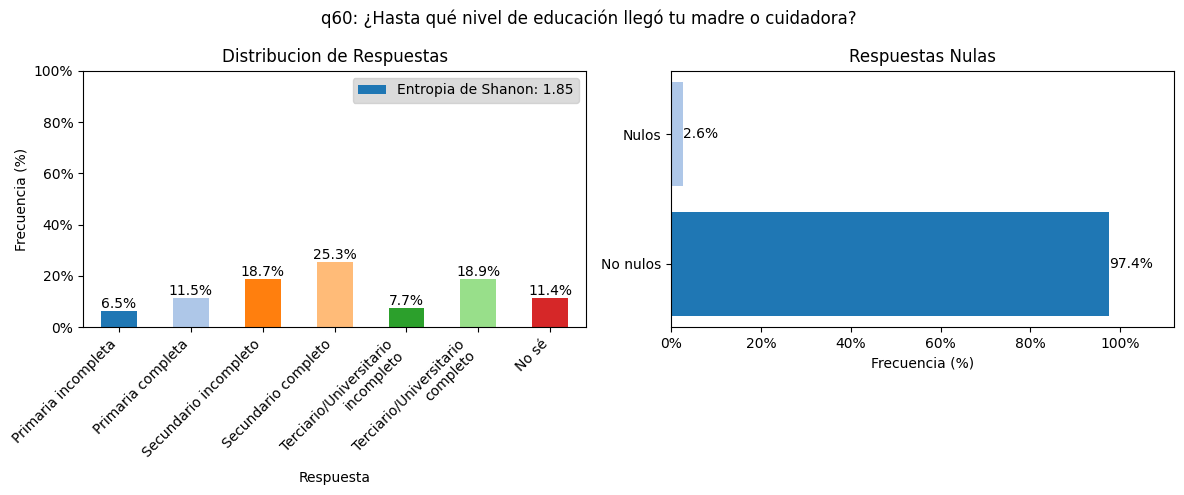

In [16]:
socioeconomicos = ["q6", "q59", "q60"]

for q in socioeconomicos:
    print_question(q)

## 5. Correlaciones

### 5.1 Correlacion entre variables de salud mental

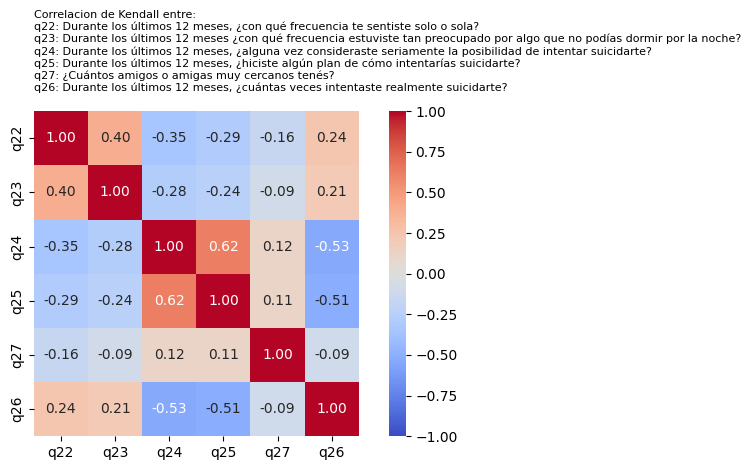

In [17]:
corr_feat = ["q22", "q23", "q24", "q25", "q27", "q26"]
corr_matrix = df[corr_feat].corr(method='kendall', numeric_only=False)
# Heatmap
titulo ="Correlacion de Kendall entre:\n"
for q in corr_feat:
   titulo += (f"{q}: {traducciones[q]}\n")
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, square=True)
#plt.ylabel('KENDALL')
plt.title(f"{titulo}",fontsize=8, loc='left')
plt.tight_layout()
plt.show()

### 5.2 Correlacion entre variables de consumo de sustancias

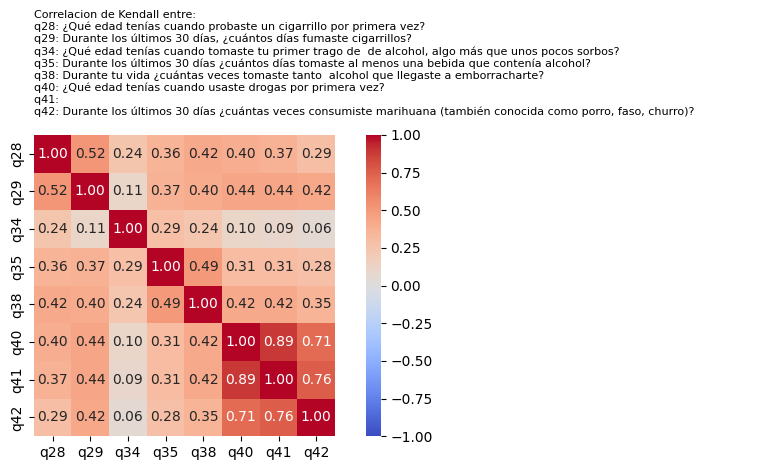

In [18]:
corr_feat = ["q28", "q29", "q34", "q35", "q38", "q40", "q41", "q42"]
corr_matrix = df[corr_feat].corr(method='kendall', numeric_only=False)
# Heatmap
titulo ="Correlacion de Kendall entre:\n"
for q in corr_feat:
   titulo += (f"{q}: {traducciones[q]}\n")
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, square=True)
#plt.ylabel('KENDALL')
plt.title(f"{titulo}",fontsize=8, loc='left')
plt.tight_layout()
plt.show()

### 5.3 Correlacion entre variables socioeconomicas

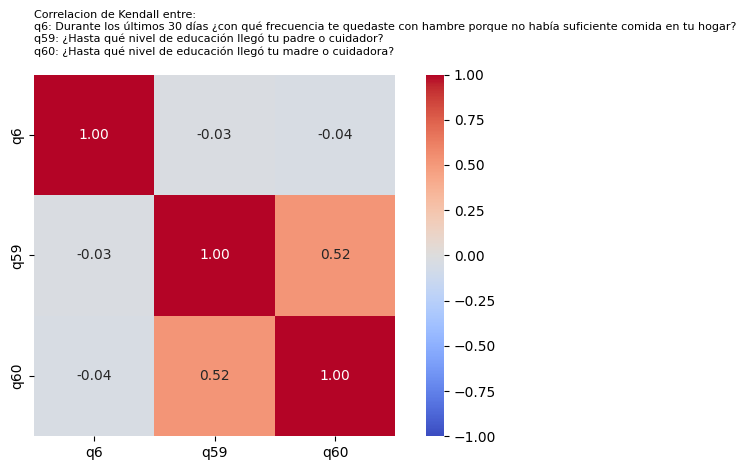

In [19]:
corr_feat = ["q6", "q59", "q60"]
corr_matrix = df[corr_feat].corr(method='kendall', numeric_only=False)
# Heatmap
titulo ="Correlacion de Kendall entre:\n"
for q in corr_feat:
   titulo += (f"{q}: {traducciones[q]}\n")
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, square=True)
#plt.ylabel('KENDALL')
plt.title(f"{titulo}",fontsize=8, loc='left')
plt.tight_layout()
plt.show()

## 5. Nulos y Outliers
No se identificaron outliers y la cantidad de nulos en todas las categorias es despreciable (menor al 10%) y de tipo MCAR asique se procedera a descartarlos a la hora de armar el dataset final